In [1]:
%matplotlib widget

In [2]:
# Script to create synthetic 3D data

import numpy as np
import emg3d 
import empymod as ep
import pandas as pd
from scipy.constants import mu_0
import matplotlib.pyplot as plt
import time
from joblib import Parallel, delayed
import sys
sys.path.insert(1, 'src')

In [3]:
sl = '0' # sys.argv[1]
co = '1' #sys.argv[2]
cr = 'c' #sys.argv[3]

In [4]:
# 0. Define instrument settings

height = 0.15
frequency = 9000
n_workers = 20

# 1. Load model

model = np.load('models/model_s'+sl+'_c'+co+'_u'+cr+'.npy')
npos = np.shape(model)[0]      # number of positions
nlay = np.shape(model)[1] - 1  # number of layers

depths = np.zeros((npos, nlay))
depths[:,1] = - model[:,0]

# 2. Create a mesh

# Define a homogoneous model
sig = np.array([100/1000])
thk = np.array([])

# Insert air layer
sig_3d = np.hstack(([1/1e6], sig))
depth_3d = np.hstack(([0], -np.cumsum(thk)))

# mesh
mesh = emg3d.construct_mesh(frequency = frequency,
                         properties = [20/1000, 20/100, sig_3d[0]],
                         center = [20,0,height],
                         mapping='Conductivity',
                         domain = ([-20, 60],[-10, 10],[-10,10]),
                         min_width_limits = [0.2, 0.2, 0.1], # changed z from 0.1 to 0.2
                         center_on_edge=False,
                         stretching= {'x': [1,1.5], 'y': [1.1,1.5], 'z': [1,1.5]}, 
                         lambda_from_center=True,
                         lambda_factor=3, 
                   #      cell_numbers=[512, 128, 128]
                   #      max_buffer = 300000,
                   #      min_width_pps = 5
                         )

# 3. Populate mesh

# Define air layer
sig_x = np.ones(mesh.n_cells)*sig_3d[0] # empty array to be populated
sig_air = np.ones(mesh.n_cells)*sig_3d[0] # air array

In [5]:
mesh

TensorMesh: 12,582,912 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x    512   -103,656.55    127,773.95      0.20 24,077.40    1.23
   y     96   -101,254.79    151,878.44      0.20 50,623.65    1.50
   z    256       -322.54    100,397.38      0.10 30,399.07    1.43

In [6]:
# Fill before position 0

x = mesh.cell_centers[:,0] <=0
y = np.ones_like(mesh.cell_centers[:,1], dtype=bool)
z_lay1 = (mesh.cell_centers[:,2] < depths[0,0]) & (mesh.cell_centers[:,2] > depths[0,1])
z_lay2 = (mesh.cell_centers[:,2] < depths[0,1]) 

sig_x[x*y*z_lay1] = model[0,1] # First layer sigma
sig_x[x*y*z_lay2] = model[0,2] # Second layer sigma

for p in range(npos):
   
    x = (mesh.cell_centers[:,0] >= p) & (mesh.cell_centers[:,0] < p+1)
    y = np.ones_like(mesh.cell_centers[:,1], dtype=bool)
    z_lay1 = (mesh.cell_centers[:,2] < depths[p,0]) & (mesh.cell_centers[:,2] > depths[p,1])
    z_lay2 = (mesh.cell_centers[:,2] < depths[p,1]) 

    sig_x[x*y*z_lay1] = model[p,1]
    sig_x[x*y*z_lay2] = model[p,2]

# fill after position npos

x = (mesh.cell_centers[:,0] > npos) 
y = np.ones_like(mesh.cell_centers[:,1], dtype=bool)
z_lay1 = (mesh.cell_centers[:,2] < depths[-1,0]) & (mesh.cell_centers[:,2] > depths[-1,1])
z_lay2 = (mesh.cell_centers[:,2] < depths[-1,1]) 

sig_x[x*y*z_lay1] = model[-1,1]
sig_x[x*y*z_lay2] = model[-1,2]

#  4. Define models

Model = emg3d.Model(mesh, 
                 property_x = sig_x,
                 mapping = 'Conductivity')

Model_air = emg3d.Model(mesh,
                     property_x = sig_air,
                     mapping = 'Conductivity')

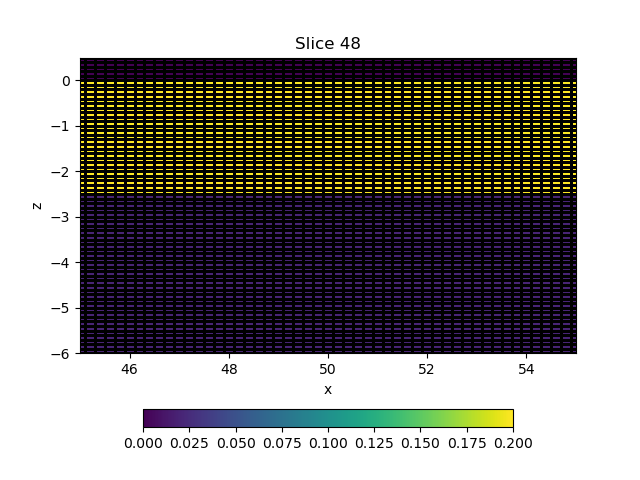

In [7]:
fig, ax = plt.subplots()

f0 = mesh.plot_slice(Model.property_x,
               normal = 'Y',
               v_type='CC',
               clim=[0,0.2],
               ax=ax,
               grid=True)
ax.set_xlim([45,55])
ax.set_ylim([-6,0.5])
#ax.scatter(src_coords[0], src_coords[2], c='r', marker = '*')
#ax.scatter(rec_coords[0], rec_coords[1]+height, c='y')

fig.colorbar(f0[0], ax=ax, orientation='horizontal', fraction=0.05)

In [8]:
np.linspace(5,14,10, endpoint=True)
#xsrc = np.linspace(-4, 39, 39+5, endpoint=True) 

array([ 5.,  6.,  7.,  8.,  9., 10., 11., 12., 13., 14.])

In [9]:
# 5. Simulate data

# xsrc is a vector of the source position, this source position makes
# the middle point start at 0 and end at 40
# 4 positions before and 3 positions after have no coverage
#xsrc = np.linspace(-4, 39, 39+5, endpoint=True) 
xsrc = np.linspace(20,22,2, endpoint=True)
#OUT = pd.DataFrame({})

startTime = time.time()
#for p in range(len(xsrc)):

def Dualem842_3D(xsrc, Model, Model_air, frequency=frequency, height=height):
   # print('Position:', p)
    print('Defining geometry')
    # Define source coordinates
    src_x = xsrc
    Hsrc_coords = [src_x, 0, height, 0, 90]
    Vsrc_coords = [src_x, 0, height, 90, 0]
    print('source:', Hsrc_coords)
    
    # Define H and V receivers coordinates
    offsets_HV = np.array([src_x+2, src_x+4, src_x+8])
    #print('offsets:',offsets_HV)
    #rec_coords = [offsets_HV, offsets_HV*0, np.ones_like(offsets_HV)*height, azi, dip]
    
    # Define P receivers coordinates
    offsets_P = np.array([src_x+2.1, src_x+4.1, src_x+8.1])
    #rec_coords_p = [offsets_P, offsets_P*0, np.ones_like(offsets_P)*height, azi, dip]
    
    # Define sources
    Hsource = emg3d.TxMagneticPoint(Hsrc_coords)
    Vsource = emg3d.TxMagneticPoint(Vsrc_coords)
    
    # Solve Electrical fields
    #print('Solving sources...')
    # Total field Hsource
    Efield_H = emg3d.solve_source(model = Model, source = Hsource, frequency = frequency)
    # Primary field Hsource
    Efield_H_p = emg3d.solve_source(model = Model_air, source = Hsource, frequency = frequency)
    
    # Total field Vsource
    Efield_V = emg3d.solve_source(model = Model, source = Vsource, frequency = frequency)
    # Primary field Vsource
    Efield_V_p = emg3d.solve_source(model = Model_air, source = Vsource, frequency = frequency)

    # Get magnetic fields
   # print('getting magnetic fields...')
    # Total magnetic field Hsource
    Hfield_H = emg3d.get_magnetic_field(model = Model, efield = Efield_H)
    # Primary magnetic field Hsource
    Hfield_H_p = emg3d.get_magnetic_field(model = Model_air, efield = Efield_H_p)
    
    # Total magnetic field Vsource
    Hfield_V = emg3d.get_magnetic_field(model = Model, efield = Efield_V)
    # Primary magnetic field Vsource
    Hfield_V_p = emg3d.get_magnetic_field(model = Model_air, efield = Efield_V_p)
    
    # Get fields at receivers
  #  print('magnetic field at receivers...')
    # For total field Hsource
    H_Hrec = Hfield_H.get_receiver((offsets_HV, offsets_HV*0, height, 0, 90))*(2j * np.pi * frequency * mu_0) 
    # For primary field Hsource
    H_Hrec_p = Hfield_H_p.get_receiver((offsets_HV, offsets_HV*0, height, 0, 90))*(2j * np.pi * frequency * mu_0) 
    # Secondary field Hsource
    H_Hrec_s = H_Hrec - H_Hrec_p
    
    # For total field Vsource
    H_Vrec = Hfield_V.get_receiver((offsets_HV, offsets_HV*0, height, 90, 0))*(2j * np.pi * frequency * mu_0) 
    # For primary field Vsource
    H_Vrec_p = Hfield_V_p.get_receiver((offsets_HV, offsets_HV*0, height, 90, 0))*(2j * np.pi * frequency * mu_0) 
    # Secondary field Vsource
    H_Vrec_s = H_Vrec - H_Vrec_p
    
    # For total field Psource
    H_Prec = Hfield_H.get_receiver((offsets_P, offsets_P*0, height, 0, 0))*(2j * np.pi * frequency * mu_0) 
    # For primary field Psource in xz direction
    H_Prec_p_xz = Hfield_H_p.get_receiver((offsets_P, offsets_P*0, height, 0, 0))*(2j * np.pi * frequency * mu_0) 
    # Secondary field Psource
    H_Prec_s = H_Prec - H_Prec_p_xz
    # Primary field Psource in zz direction
    H_Prec_p = Hfield_H_p.get_receiver((offsets_P, offsets_P*0, height, 0, 90))*(2j * np.pi * frequency * mu_0)
    
     # Calculate output components OP and IP
 #   print('getting output components')
    # Horizontal coplanar
    op_h = (H_Hrec_s/H_Hrec_p).imag.amp()
    ip_h = (H_Hrec_s/H_Hrec_p).real.amp()
    #OUT.append([op_h, ip_h])
    # Vertical coplanar
    op_v = (H_Vrec_s/H_Vrec_p).imag.amp()
    ip_v = (H_Vrec_s/H_Vrec_p).real.amp()
    #OUT.append([op_v, ip_v])
    # Perpendicular
    op_p = (H_Prec_s/H_Prec_p).imag.amp()
    ip_p = (H_Prec_s/H_Prec_p).real.amp()
    #OUT.append([op_p, ip_p])
    
    OUT_i = pd.DataFrame({'geom'  : ['H2', 'H4', 'H8', 'V2', 'V4', 'V8', 'P2', 'P4', 'P8'],
                          'src_x' : [Hsrc_coords[0], Hsrc_coords[0], Hsrc_coords[0],
                                     Vsrc_coords[0], Vsrc_coords[0], Vsrc_coords[0],
                                     Hsrc_coords[0], Hsrc_coords[0], Hsrc_coords[0]],
                          'rec_x' : np.hstack((offsets_HV, offsets_HV, offsets_P)),
                          'midpx' : np.hstack((Hsrc_coords[0] + (offsets_HV - Hsrc_coords[0])/2,
                                               Vsrc_coords[0] + (offsets_HV - Vsrc_coords[0])/2,
                                               Hsrc_coords[0] + (offsets_P - Hsrc_coords[0])/2)),
                          'op'    : np.hstack((op_h, op_v, op_p)),
                          'ip'    : np.hstack((ip_h, ip_v, ip_p)) 
                          })
    
    #OUT = pd.concat([OUT, OUT_i], ignore_index=True)
    print()
    return OUT_i
                 
OUT = Parallel(n_jobs=n_workers,verbose=0)(delayed(Dualem842_3D)(xsrc[p], 
                         Model, Model_air) for p in range(len(xsrc)))

print(OUT)

#Dat = Dualem842_3D(20, Model, Model_air)
                 
print()
endTime = time.time()
print('Done in', (endTime - startTime), 'seconds!')

[  geom  src_x  rec_x  midpx        op        ip
0   H2   20.0   22.0  21.00  0.009157  0.000723
1   H4   20.0   24.0  22.00  0.023821  0.004416
2   H8   20.0   28.0  24.00  0.042189  0.022196
3   V2   20.0   22.0  21.00  0.009651  0.000407
4   V4   20.0   24.0  22.00  0.034373  0.002733
5   V8   20.0   28.0  24.00  0.100280  0.015742
6   P2   20.0   22.1  21.05  0.012446  0.000256
7   P4   20.0   24.1  22.05  0.043770  0.002178
8   P8   20.0   28.1  24.05  0.126448  0.015200,   geom  src_x  rec_x  midpx        op        ip
0   H2   22.0   24.0  23.00  0.009158  0.000723
1   H4   22.0   26.0  24.00  0.023822  0.004410
2   H8   22.0   30.0  26.00  0.042206  0.022172
3   V2   22.0   24.0  23.00  0.009652  0.000406
4   V4   22.0   26.0  24.00  0.034379  0.002721
5   V8   22.0   30.0  26.00  0.100330  0.015677
6   P2   22.0   24.1  23.05  0.012446  0.000256
7   P4   22.0   26.1  24.05  0.043769  0.002177
8   P8   22.0   30.1  26.05  0.126445  0.015193]

Done in 4354.900761604309 seconds!


In [10]:
#OUT_save = pd.concat(OUT)

In [11]:
#OUT_save.to_pickle('data/OUT_save.pkl')

In [12]:
#OUT =  np.load('data/OUT_save.pkl', allow_pickle=True)

In [13]:
def FDEM1D(sgm, thk, height=0.15) :
    """ 1D FDEM response 
        
    Parameters
    ----------
    sgm : array
           Array of electrical conductivities [S/m], len(sigma) = nlay

    thk : array
           Array of thicknesses [m], len(thk) = nlay - 1

    Freq : frequency of device [Hz]

    coilOrient : array of strings
                  coil orientations: 'H' for horizontal coplanar, 
                  'V' for vertical coplanar, 'P' for perpendicular

    coilSpacing : array
                    separations of the transmitter and receiver coils [m]

    height : float
                height of the device with respect to ground [m]
                
    norm : normalize values with respect to offset

    Returns
    -------
    Array [OP, IP]

    """  
    # Set geometry
    Freq = 9000
    coilSpacing = [2, 4, 8]
    pcoilSpacing = [2.1, 4.1, 8.1]
    coilOrient = np.array(['H', 'V', 'P'])
    #height = 0

    # Source and receivers geometry [x, y, z]
    source    = [0, 0, -height]
    receivers = [coilSpacing, np.zeros(len(coilSpacing)), -height]    
    preceivers = [pcoilSpacing, np.zeros(len(pcoilSpacing)), -height]

    # Depth and resistivity
    res_air = 1e6
    res = np.hstack((res_air, 1/sgm))
    depth = np.hstack((0, np.cumsum(thk)))
    # Empty array to store responses
    OP = []
    IP = []
    
    if any(coilOrient == 'H'):

        H_Hs = ep.dipole(source, receivers, depth, res, Freq, ab = 66, xdirect=None, 
                          verb=0)*(2j * np.pi * Freq * mu_0) 
        H_Hp = ep.dipole(source, receivers, depth=[], res=[res_air], freqtime = Freq,
                         ab = 66, verb=0)*(2j * np.pi * Freq * mu_0)   
        op = (H_Hs/H_Hp).imag.amp()# * norm
        ip = (H_Hs/H_Hp).real.amp()# * norm
        OP.append(op) 
        IP.append(ip)

    if any(coilOrient == 'V'):
        V_Hs = ep.dipole(source, receivers, depth, res, Freq, ab =55, xdirect=None, 
                         verb=0)*(2j * np.pi * Freq * mu_0) 
        V_Hp = ep.dipole(source, receivers, depth=[], res=[res_air], freqtime=Freq, 
                         ab=55, verb=0)*(2j * np.pi * Freq * mu_0)
        op = (V_Hs/V_Hp).imag.amp()# * norm
        ip = (V_Hs/V_Hp).real.amp()# * norm
        OP.append(op)
        IP.append(ip)

    if any(coilOrient == 'P'):
        # Maybe put 0.1m in receiver offset
        P_Hs = ep.dipole(source, preceivers, depth, res, Freq, ab=46, xdirect=None, 
                         verb=0)*(2j * np.pi * Freq * mu_0) 
        P_Hp = ep.dipole(source, preceivers, depth=[], res=[res_air], freqtime= Freq,
                         ab=66, verb=0)*(2j * np.pi * Freq * mu_0) 
        op = (P_Hs/P_Hp).imag.amp()# * norm
        ip = (P_Hs/P_Hp).real.amp()# * norm
        OP.append(op)
        IP.append(ip)
        
    return np.array([OP, IP]).ravel() 

In [14]:
data_1D = []
for x in xsrc:
    x_int = int(x)
    data_1D.append(FDEM1D(model[x_int,1:], model[x_int,0]))

In [15]:
data_3D = []
for x in range(len(xsrc)):
    
   # data_3D.append(np.hstack((OUT[x*9:(x+1)*9]['op'], OUT[x*9:(x+1)*9]['ip'])))
    data_3D.append(np.hstack((OUT[x]['op'], OUT[x]['ip'])))

In [16]:
data_1D = np.array(data_1D)
data_3D = np.array(data_3D)

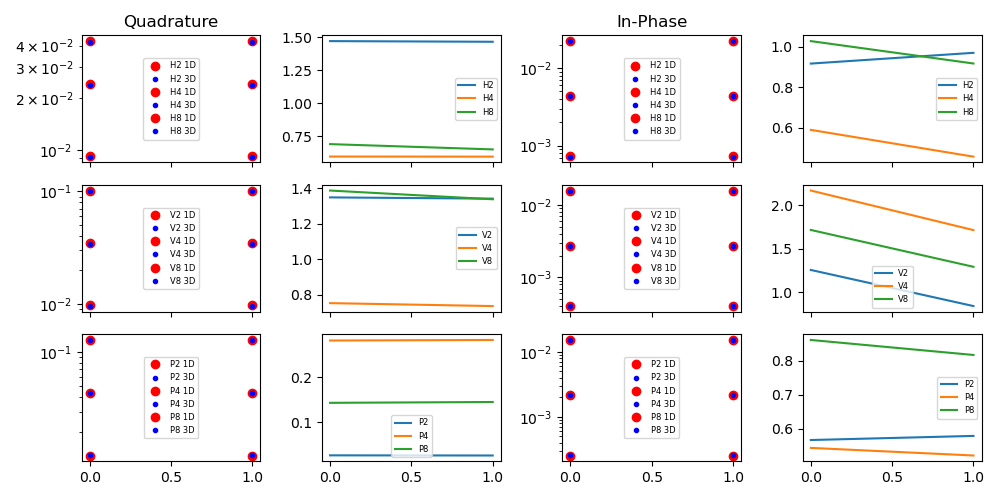

In [17]:
fig, ax = plt.subplots(3,4, sharex=True, figsize=(10,5))

ax[0,0].semilogy(data_1D[:,0], 'or', label='H2 1D')
ax[0,0].semilogy(data_3D[:,0], '.b', label= 'H2 3D')
ax[0,1].plot(100*np.abs((data_1D[:,0] - data_3D[:,0])/data_1D[:,0]), label='H2')


ax[0,0].semilogy(data_1D[:,1], 'or', label='H4 1D')
ax[0,0].semilogy(data_3D[:,1], '.b', label= 'H4 3D')
ax[0,1].plot(100*np.abs((data_1D[:,1] - data_3D[:,1])/data_1D[:,1]), label='H4')

ax[0,0].semilogy(data_1D[:,2], 'or', label='H8 1D')
ax[0,0].semilogy(data_3D[:,2], '.b', label= 'H8 3D')
ax[0,1].plot(100*np.abs((data_1D[:,2] - data_3D[:,2])/data_1D[:,2]), label='H8')
ax[0,0].legend(fontsize=6)
ax[0,1].legend(fontsize=6)
ax[0,0].set_title('Quadrature')

ax[1,0].semilogy(data_1D[:,3], 'or', label='V2 1D')
ax[1,0].semilogy(data_3D[:,3], '.b', label= 'V2 3D')
ax[1,1].plot(100*np.abs((data_1D[:,3] - data_3D[:,3])/data_1D[:,3]), label='V2')

ax[1,0].semilogy(data_1D[:,4], 'or', label='V4 1D')
ax[1,0].semilogy(data_3D[:,4], '.b', label= 'V4 3D')
ax[1,1].plot(100*np.abs((data_1D[:,4] - data_3D[:,4])/data_1D[:,4]), label='V4')

ax[1,0].semilogy(data_1D[:,5], 'or', label='V8 1D')
ax[1,0].semilogy(data_3D[:,5], '.b', label= 'V8 3D')
ax[1,1].plot(100*np.abs((data_1D[:,5] - data_3D[:,5])/data_1D[:,5]), label='V8')
ax[1,0].legend(fontsize=6)
ax[1,1].legend(fontsize=6)

ax[2,0].semilogy(data_1D[:,6], 'or', label='P2 1D')
ax[2,0].semilogy(data_3D[:,6], '.b', label= 'P2 3D')
ax[2,1].plot(100*np.abs((data_1D[:,6] - data_3D[:,6])/data_1D[:,6]), label='P2')

ax[2,0].semilogy(data_1D[:,7], 'or', label='P4 1D')
ax[2,0].semilogy(data_3D[:,7], '.b', label= 'P4 3D')
ax[2,1].plot(100*np.abs((data_1D[:,7] - data_3D[:,7])/data_1D[:,7]), label='P4')

ax[2,0].semilogy(data_1D[:,8], 'or', label='P8 1D')
ax[2,0].semilogy(data_3D[:,8], '.b', label= 'P8 3D')
ax[2,1].plot(100*np.abs((data_1D[:,8] - data_3D[:,8])/data_1D[:,8]), label='P8')
ax[2,0].legend(fontsize=6)
ax[2,1].legend(fontsize=6)

# In-Phase
ax[0,2].semilogy(data_1D[:,9], 'or', label='H2 1D')
ax[0,2].semilogy(data_3D[:,9], '.b', label= 'H2 3D')
ax[0,3].plot(100*np.abs((data_1D[:,9] - data_3D[:,9])/data_1D[:,9]), label='H2')

ax[0,2].semilogy(data_1D[:,10], 'or', label='H4 1D')
ax[0,2].semilogy(data_3D[:,10], '.b', label= 'H4 3D')
ax[0,3].plot(100*np.abs((data_1D[:,10] - data_3D[:,10])/data_1D[:,10]), label='H4')

ax[0,2].semilogy(data_1D[:,11], 'or', label='H8 1D')
ax[0,2].semilogy(data_3D[:,11], '.b', label= 'H8 3D')
ax[0,3].plot(100*np.abs((data_1D[:,11] - data_3D[:,11])/data_1D[:,11]), label='H8')

ax[0,2].legend(fontsize=6)
ax[0,3].legend(fontsize=6)
ax[0,2].set_title('In-Phase')

ax[1,2].semilogy(data_1D[:,12], 'or', label='V2 1D')
ax[1,2].semilogy(data_3D[:,12], '.b', label= 'V2 3D')
ax[1,3].plot(100*np.abs((data_1D[:,12] - data_3D[:,12])/data_1D[:,12]), label='V2')

ax[1,2].semilogy(data_1D[:,13], 'or', label='V4 1D')
ax[1,2].semilogy(data_3D[:,13], '.b', label= 'V4 3D')
ax[1,3].plot(100*np.abs((data_1D[:,13] - data_3D[:,13])/data_1D[:,13]), label='V4')

ax[1,2].semilogy(data_1D[:,14], 'or', label='V8 1D')
ax[1,2].semilogy(data_3D[:,14], '.b', label= 'V8 3D')
ax[1,3].plot(100*np.abs((data_1D[:,14] - data_3D[:,14])/data_1D[:,14]), label='V8')

ax[1,2].legend(fontsize=6)
ax[1,3].legend(fontsize=6)

ax[2,2].semilogy(data_1D[:,15], 'or', label='P2 1D')
ax[2,2].semilogy(data_3D[:,15], '.b', label= 'P2 3D')
ax[2,3].plot(100*np.abs((data_1D[:,15] - data_3D[:,15])/data_1D[:,15]), label='P2')

ax[2,2].semilogy(data_1D[:,16], 'or', label='P4 1D')
ax[2,2].semilogy(data_3D[:,16], '.b', label= 'P4 3D')
ax[2,3].plot(100*np.abs((data_1D[:,16] - data_3D[:,16])/data_1D[:,16]), label='P4')

ax[2,2].semilogy(data_1D[:,17], 'or', label='P8 1D')
ax[2,2].semilogy(data_3D[:,17], '.b', label= 'P8 3D')
ax[2,3].plot(100*np.abs((data_1D[:,17] - data_3D[:,17])/data_1D[:,17]), label='P8')

ax[2,2].legend(fontsize=6)
ax[2,3].legend(fontsize=6)

plt.tight_layout()

